# Notebook 6 — Soft-Voting Ensemble

Combines the three multilingual transformers by averaging their class probabilities on the bilingual test set, and compares every architecture in one table.

Setup

In [2]:
import os, json, glob, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, classification_report)
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

SRC ='/content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-/bilingual results'

FIG =f'{SRC}/figures'
RES=f'{SRC}/tables'
for p in (FIG, RES): os.makedirs(p, exist_ok=True)

if not os.path.isdir(SRC):
    raise FileNotFoundError(f"Folder not found on Drive: {SRC}")

print(f"results -> {SRC}")
print(f"figures -> {FIG}")
print(f"tables  -> {RES}")

Mounted at /content/drive
results -> /content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-/bilingual results
figures -> /content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-/bilingual results/figures
tables  -> /content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-/bilingual results/tables


 Load and verify

In [ ]:
MODELS= ['distilbert', 'mbert', 'xlmr']
CONDITIONS = ['full', 'en', 'es']
EXPECTED_N= {'full': 13984, 'en': 9843, 'es': 4141}

missing =[]
for m in MODELS:
    for c in CONDITIONS:
        for kind in ['probs', 'labels']:
            f=f'{SRC}/{m}_bilingual_{c}_{kind}.npy'
            if not os.path.exists(f):
                missing.append(os.path.basename(f))
if missing:
    print("MISSING", len(missing), "file(s):")
    for f in missing: print("  ", f)
    raise FileNotFoundError("Cannot build the ensemble until these are present")
print("all 18 files present")

all 18 files present


In [ ]:
def load_probs(path):
    q = np.load(path).astype(np.float64)
    if q[:, 1].max() < 0.75:
        p1 = np.clip((np.log(q[:, 1] / q[:, 0]) + 1) / 2, 0, 1)
        fixed = np.stack([1 - p1, p1], 1)
        return fixed
    return q

probs, labels={}, {}
for c in CONDITIONS:
    print(f"[{c}]")
    for m in MODELS:
        probs[(m, c)] =load_probs(f'{SRC}/{m}_bilingual_{c}_probs.npy')
        l = np.load(f'{SRC}/{m}_bilingual_{c}_labels.npy')
        if c in labels:
            assert np.array_equal(labels[c], l), (
                f"{m} {c}: label array differs from the other models. "
                "Rows are not aligned and the arrays must not be averaged.")
        else:
            labels[c]=l
        assert len(l) ==EXPECTED_N[c], f"{m} {c}: expected {EXPECTED_N[c]} rows, got {len(l)}"
    print(f"  n={EXPECTED_N[c]}  rows aligned across all three models")

assert EXPECTED_N['en']+ EXPECTED_N['es'] == EXPECTED_N['full']
print("\nverified: probabilities normalised, uncompressed, and row-aligned")


[full]
  n=13984  rows aligned across all three models
[en]
  n=9843  rows aligned across all three models
[es]
  n=4141  rows aligned across all three models

verified: probabilities normalised, uncompressed, and row-aligned


Soft voting

In [ ]:
ens_probs, ens_preds={},{}
for c in CONDITIONS:
    ens_probs[c]= np.mean([probs[(m, c)] for m in MODELS],axis=0)
    ens_preds[c]=ens_probs[c].argmax(1)

print("ensemble predicted class distribution (full test set)")
print(pd.Series(ens_preds['full']).value_counts().rename({0: 'Non-Abusive', 1: 'Abusive'}).to_string())

ensemble predicted class distribution (full test set)
Abusive        7114
Non-Abusive    6870


Evaluation

In [ ]:
NAMES={'full': 'Bilingual (EN+ES)','en': 'English subset', 'es': 'Spanish subset'}
for c in CONDITIONS:
    y, p=labels[c],ens_preds[c]
    print("=" * 58)
    print(f"  Soft-Voting Ensemble - {NAMES[c]}   (n={len(y)})")
    print("=" * 58)
    print(f"  Accuracy:{accuracy_score(y, p):.4f}")
    print(f"  Macro Precision: {precision_score(y, p, average='macro'):.4f}")
    print(f"  Macro Recall:{recall_score(y, p, average='macro'):.4f}")
    print(f"  Macro F1:{f1_score(y, p, average='macro'):.4f}")
    print(classification_report(y, p, target_names=['Non-Abusive', 'Abusive'], digits=4))

  Soft-Voting Ensemble - Bilingual (EN+ES)   (n=13984)
  Accuracy:        0.9184
  Macro Precision: 0.9185
  Macro Recall:    0.9184
  Macro F1:        0.9184
              precision    recall  f1-score   support

 Non-Abusive     0.9262    0.9094    0.9177      6997
     Abusive     0.9109    0.9274    0.9191      6987

    accuracy                         0.9184     13984
   macro avg     0.9185    0.9184    0.9184     13984
weighted avg     0.9185    0.9184    0.9184     13984

  Soft-Voting Ensemble - English subset   (n=9843)
  Accuracy:        0.9309
  Macro Precision: 0.9310
  Macro Recall:    0.9309
  Macro F1:        0.9309
              precision    recall  f1-score   support

 Non-Abusive     0.9372    0.9239    0.9305      4926
     Abusive     0.9248    0.9380    0.9313      4917

    accuracy                         0.9309      9843
   macro avg     0.9310    0.9309    0.9309      9843
weighted avg     0.9310    0.9309    0.9309      9843

  Soft-Voting Ensemble - Spanish

In [ ]:
rows =[]
for c in CONDITIONS:
    y=labels[c]
    singles ={m: f1_score(y, probs[(m, c)].argmax(1), average='macro') for m in MODELS}
    e = f1_score(y, ens_preds[c], average='macro')
    best_m =max(singles,key=singles.get)
    preds_m= np.stack([probs[(m, c)].argmax(1) for m in MODELS])
    unanimous= (preds_m== preds_m[0]).all(0).mean()
    rows.append({
        'Condition':NAMES[c],**{m: round(singles[m], 4) for m in MODELS},
        'Ensemble': round(e, 4),'Best single': best_m,
        'Gain (pp)': round(100 * (e - singles[best_m]), 2),
        'Unanimous (%)': round(100 * unanimous, 2),
    })

gain_df=pd.DataFrame(rows)
gain_df.to_csv(f'{RES}/ensemble_gain.csv', index=False)
print(gain_df.to_string(index=False))

        Condition  distilbert  mbert   xlmr  Ensemble Best single  Gain (pp)  Unanimous (%)
Bilingual (EN+ES)      0.9088 0.9103 0.9180    0.9184        xlmr       0.04          91.55
   English subset      0.9261 0.9264 0.9297    0.9309        xlmr       0.12          93.70
   Spanish subset      0.8676 0.8719 0.8904    0.8887        xlmr      -0.17          86.45


Model comparison


In [ ]:
LABELS = {'bilstm': 'BiLSTM', 'distilbert': 'DistilBERT', 'mbert': 'mBERT', 'xlmr': 'XLM-R', 'beto': 'BETO', 'ensemble': 'Ensemble', 'lora': 'LoRA Mistral 7B'}
FALLBACK = {
    'distilbert_en_only': {'f1': 0.9262, 'nonab': 0.9178, 'ab': 0.9347,'src': 'Notebook 5 cell output'},
}
_from_fallback = set()
def read_metrics(tag):
    f = f'{SRC}/{tag}_metrics.json'
    if not os.path.exists(f):
        if tag in FALLBACK:
            _from_fallback.add(tag)
            return FALLBACK[tag]
        return None
    rep= json.load(open(f))
    return {'f1':round(rep['macro avg']['f1-score'], 4),
            'nonab': round(rep['Non-Abusive']['recall'], 4),
            'ab': round(rep['Abusive']['recall'], 4)}

def f1_of(tag):
    m =read_metrics(tag)
    return m['f1'] if m else None

TAGS = {
    'full': '{m}_bilingual_full',
    'en':'{m}_bilingual_en',
    'es':'{m}_bilingual_es',
    'ENo':'{m}_en_only',
    'ESo':'{m}_es_only',
    'e2s':'{m}_en2es',
    's2e':'{m}_es2en',
}

def get(m, key):
    return f1_of(TAGS[key].format(m=m))

STALE = {'bilstm_en_only': (0.8957, 0.9100), 'bilstm_es_only': (0.8282, 0.7691)}
for tag, (bad, good) in STALE.items():
    v = f1_of(tag)
    if v is not None and abs(v - bad) < 5e-4:
        raise ValueError(
            f"{tag} reads {v}, the superseded value. Expected {good}. "
            f"Re-run Notebook 4 so it writes to '{os.path.basename(D)}'.")

rows = []
for m in ['bilstm', 'distilbert', 'mbert', 'xlmr','beto']:
    r = {'Model': LABELS[m],
         'Bilingual F1': get(m, 'full'),
         'EN F1':get(m,'en'),
         'ES F1':get(m, 'es'),
         'EN-only': get(m,'ENo'),
         'ES-only': get(m, 'ESo'),
         'EN→ES':get(m,'e2s'),
         'ES→EN':get(m, 's2e')}
    if any(v is not None for v in list(r.values())[1:]):
        rows.append(r)

rows.append({'Model': 'Ensemble',
             'Bilingual F1': round(f1_score(labels['full'], ens_preds['full'],average='macro'), 4),
             'EN F1':round(f1_score(labels['en'],ens_preds['en'],average='macro'), 4),
             'ES F1':round(f1_score(labels['es'],ens_preds['es'], average='macro'), 4),
             'EN-only': None, 'ES-only': None,'EN→ES': None, 'ES→EN': None})

comparison_df= (pd.DataFrame(rows).sort_values('Bilingual F1', ascending=False, na_position='last').reset_index(drop=True))
comparison_df['EN-ES gap (pp)']=((comparison_df['EN F1'] - comparison_df['ES F1']) * 100).round(2)
comparison_df.to_csv(f'{RES}/full_model_comparison.csv', index=False)
print(comparison_df.to_string(index=False))

if _from_fallback:
    print("\nquoted from notebook output, not from a saved file:")
    for t in sorted(_from_fallback):
        print(f"  {t}: {FALLBACK[t]['src']}")

blank_cells = [(r['Model'], k) for r in rows for k in['EN-only', 'ES-only', 'EN→ES', 'ES→EN']
               if r.get(k) is None and r['Model'] != 'Ensemble']
if blank_cells:
    print("\nno run on file for:")
    for model, k in blank_cells:
        print(f"  {model:12s} {k}")


     Model  Bilingual F1  EN F1  ES F1  EN-only  ES-only  EN→ES  ES→EN  EN-ES gap (pp)
  Ensemble        0.9184 0.9309 0.8887      NaN      NaN    NaN    NaN            4.22
     XLM-R        0.9180 0.9297 0.8904   0.9294   0.8860 0.4942 0.6313            3.93
     mBERT        0.9103 0.9264 0.8719   0.9257   0.8773 0.4077 0.5456            5.45
DistilBERT        0.9088 0.9261 0.8676   0.9262   0.8684 0.4301 0.5396            5.85
    BiLSTM        0.8864 0.9022 0.8490   0.9100   0.7691 0.3760 0.4462            5.32
      BETO           NaN    NaN    NaN      NaN   0.8990    NaN 0.6194             NaN

quoted from notebook output, not from a saved file:
  distilbert_en_only: Notebook 5 cell output

no run on file for:
  BETO         EN-only
  BETO         EN→ES


Per-class recall in both transfer directions. This is the table that shows whether the collapse under transfer favours the same class in both directions.

In [ ]:
rows =[]
for m in ['bilstm', 'distilbert', 'mbert', 'xlmr', 'beto']:
    for key, direction in [('e2s', 'EN→ES'), ('s2e', 'ES→EN')]:
        met=read_metrics(TAGS[key].format(m=m))
        if met:
            rows.append({'Model':LABELS[m], 'Direction': direction,'Macro F1':met['f1'],'Non-abusive recall': met['nonab'],'Abusive recall': met['ab']})

recall_df =pd.DataFrame(rows).sort_values(['Direction', 'Macro F1'])
recall_df.to_csv(f'{RES}/cross_lingual_per_class_recall.csv',index=False)
print(recall_df.to_string(index=False))

recall_df['Favours'] = np.where(recall_df['Non-abusive recall'] > recall_df['Abusive recall'],'non-abusive', 'abusive')
print("\n" + recall_df.pivot(index='Model', columns='Direction', values='Favours').to_string())

     Model Direction  Macro F1  Non-abusive recall  Abusive recall
    BiLSTM     EN→ES    0.3760              0.7190          0.1382
     mBERT     EN→ES    0.4077              0.9218          0.0957
DistilBERT     EN→ES    0.4301              0.9329          0.1169
     XLM-R     EN→ES    0.4942              0.7716          0.2783
    BiLSTM     ES→EN    0.4462              0.1959          0.7968
DistilBERT     ES→EN    0.5396              0.8843          0.2790
     mBERT     ES→EN    0.5456              0.8985          0.2794
      BETO     ES→EN    0.6194              0.8325          0.4360
     XLM-R     ES→EN    0.6313              0.8831          0.4190

Direction         EN→ES        ES→EN
Model                               
BETO                NaN  non-abusive
BiLSTM      non-abusive      abusive
DistilBERT  non-abusive  non-abusive
XLM-R       non-abusive  non-abusive
mBERT       non-abusive  non-abusive


Figures

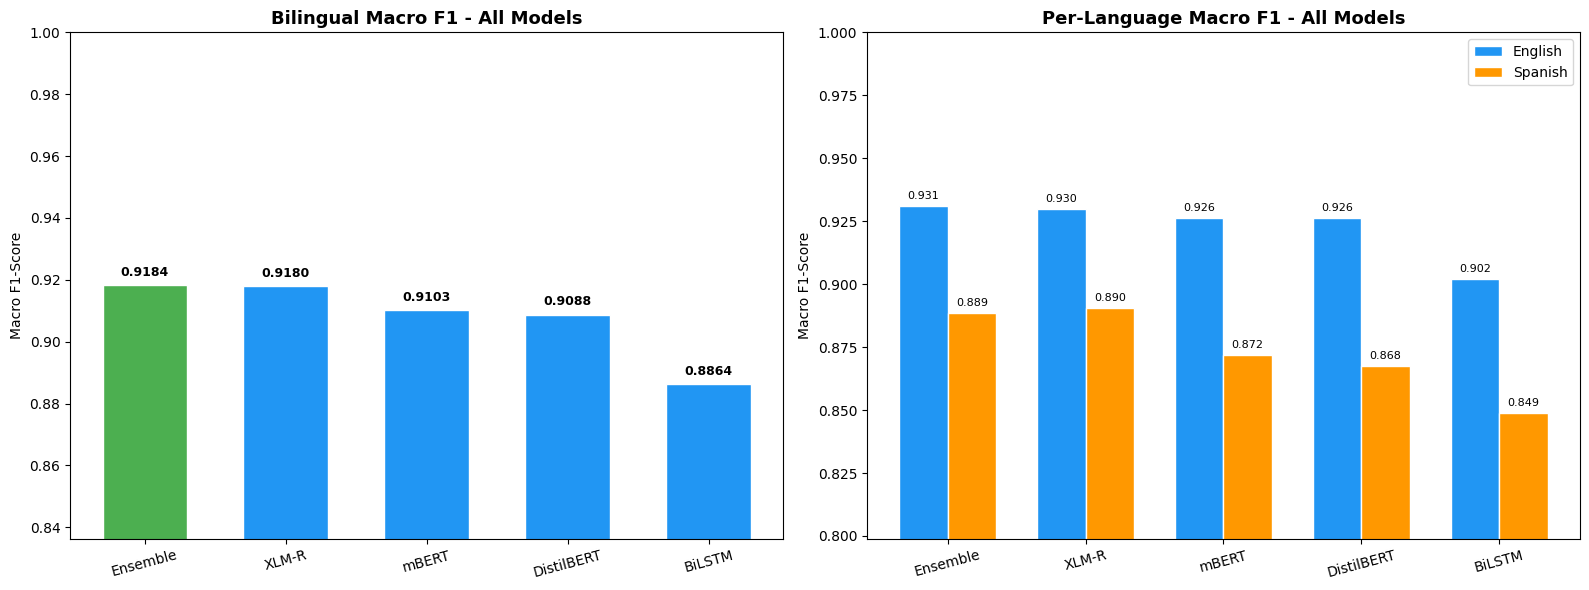

In [ ]:
plot_df =comparison_df.dropna(subset=['Bilingual F1'])
fig,axes = plt.subplots(1, 2, figsize=(16, 6))
ax=axes[0]
colors =['#4CAF50' if m == 'Ensemble' else '#2196F3' for m in plot_df['Model']]
bars=ax.bar(plot_df['Model'], plot_df['Bilingual F1'], color=colors,edgecolor='white', width=0.6)
ax.set_title('Bilingual Macro F1 - All Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Macro F1-Score')
lo =plot_df['Bilingual F1'].min()
ax.set_ylim(max(0, lo - 0.05), 1.0)
for b, s in zip(bars, plot_df['Bilingual F1']):
    ax.text(b.get_x()+b.get_width() / 2, b.get_height() + 0.002,
            f'{s:.4f}',ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.tick_params(axis='x',rotation=15)

ax =axes[1]
lang_df= plot_df.dropna(subset=['EN F1', 'ES F1'])
x, w =np.arange(len(lang_df)), 0.35
b1 =ax.bar(x - w / 2, lang_df['EN F1'], w, label='English', color='#2196F3', edgecolor='white')
b2=ax.bar(x + w / 2, lang_df['ES F1'], w, label='Spanish',color='#FF9800', edgecolor='white')
ax.set_title('Per-Language Macro F1 - All Models',fontsize=13, fontweight='bold')
ax.set_ylabel('Macro F1-Score')
ax.set_ylim(max(0, min(lang_df['ES F1'].min(), lang_df['EN F1'].min()) - 0.05), 1.0)
ax.set_xticks(x); ax.set_xticklabels(lang_df['Model'], rotation=15); ax.legend()
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.002,
            f'{b.get_height():.3f}',ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG}/full_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

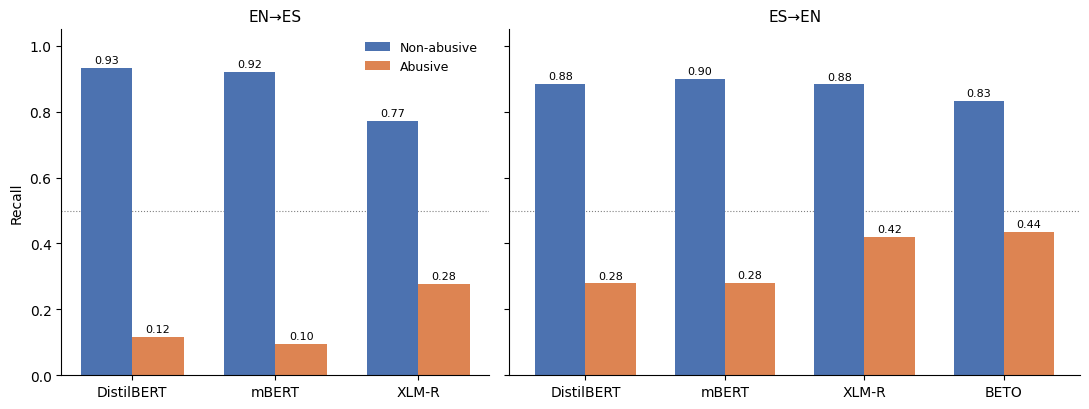

saved: /content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-/bilingual results/figures/fig_4_1_per_class_recall.png
  EN→ES  DistilBERT  non-abusive 0.9329   abusive 0.1169
  EN→ES  mBERT       non-abusive 0.9218   abusive 0.0957
  EN→ES  XLM-R       non-abusive 0.7716   abusive 0.2783
  ES→EN  DistilBERT  non-abusive 0.8843   abusive 0.2790
  ES→EN  mBERT       non-abusive 0.8985   abusive 0.2794
  ES→EN  XLM-R       non-abusive 0.8831   abusive 0.4190
  ES→EN  BETO        non-abusive 0.8325   abusive 0.4360


In [ ]:
import json, os
import numpy as np
import matplotlib.pyplot as plt

PANELS = [
    ('EN\u2192ES', [('DistilBERT', 'distilbert_en2es'),
                   ('mBERT','mbert_en2es'),
                   ('XLM-R','xlmr_en2es')]),
    ('ES\u2192EN', [('DistilBERT', 'distilbert_es2en'),
                   ('mBERT','mbert_es2en'),
                   ('XLM-R','xlmr_es2en'),
                   ('BETO','beto_es2en')]),
]

def recalls(tag):
    p =f'{SRC}/{tag}_metrics.json'
    assert os.path.exists(p), f'missing: {p}'
    r =json.load(open(p))
    return r['Non-Abusive']['recall'], r['Abusive']['recall']

fig, axes =plt.subplots(1, 2, figsize=(11, 4.2), sharey=True,gridspec_kw={'width_ratios': [3, 4]})
W =0.36
NONAB,AB = '#4C72B0','#DD8452'

for ax, (direction, models) in zip(axes, PANELS):
    names= [n for n, _ in models]
    vals  =[recalls(t) for _, t in models]
    x =np.arange(len(names))
    b1= ax.bar(x - W/2,[v[0] for v in vals], W, label='Non-abusive', color=NONAB)
    b2 =ax.bar(x + W/2, [v[1] for v in vals],W, label='Abusive',color=AB)
    for b in (b1, b2):
        ax.bar_label(b, fmt='%.2f', fontsize=8, padding=2)

    ax.set_xticks(x); ax.set_xticklabels(names)
    ax.set_title(direction, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='grey', lw=0.8, ls=':',zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Recall')
axes[0].legend(frameon=False, loc='upper right', fontsize=9)
plt.tight_layout()

os.makedirs(FIG, exist_ok=True)
out =f'{FIG}/fig_4_1_per_class_recall.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('saved:', out)

for direction, models in PANELS:
    for name, tag in models:
        na, ab = recalls(tag)
        print(f'  {direction}  {name:11s} non-abusive {na:.4f}   abusive {ab:.4f}')

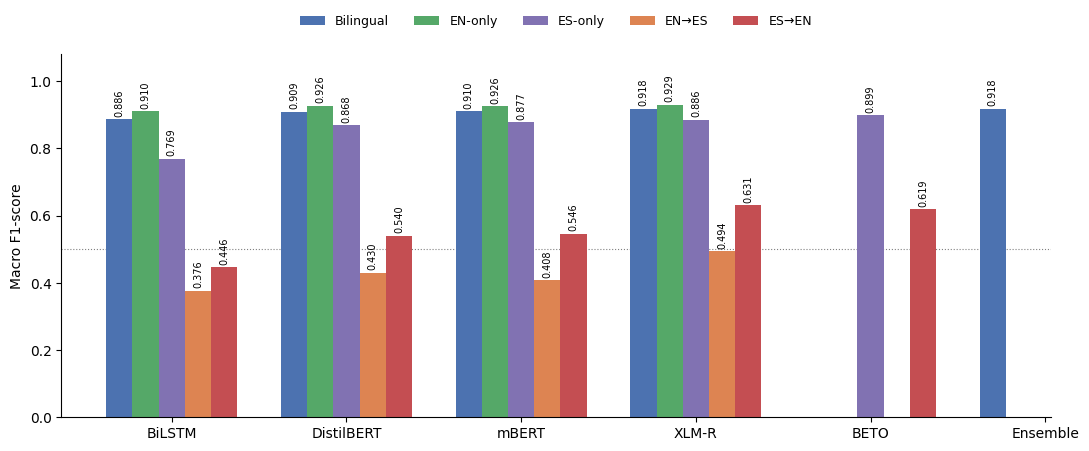

saved: /content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-/bilingual results/figures/fig_4_1_macro_f1_by_condition.png
  BiLSTM      0.8864  0.9100  0.7691  0.3760  0.4462
  DistilBERT  0.9088  0.9262  0.8684  0.4301  0.5396
  mBERT       0.9103  0.9257  0.8773  0.4077  0.5456
  XLM-R       0.9180  0.9294  0.8860  0.4942  0.6313
  BETO          n/a     n/a   0.8990    n/a   0.6194
  Ensemble    0.9184    n/a     n/a     n/a     n/a 


In [ ]:
import numpy as np, matplotlib.pyplot as plt
FALLBACK = {'distilbert_en_only': 0.9262}
CONDITIONS = [('Bilingual', '{m}_bilingual_full'), ('EN-only', '{m}_en_only'),('ES-only',   '{m}_es_only'),        ('EN\u2192ES', '{m}_en2es'), ('ES\u2192EN', '{m}_es2en')]
MODELS = [('BiLSTM','bilstm'), ('DistilBERT','distilbert'), ('mBERT','mbert'), ('XLM-R','xlmr'), ('BETO','beto'), ('Ensemble','ensemble')]

def f1(tag):
    p =f'{SRC}/{tag}_metrics.json'
    if os.path.exists(p):
        return json.load(open(p))['macro avg']['f1-score']
    return FALLBACK.get(tag)

vals ={(m, c): f1(pat.format(m=key)) for c,pat in CONDITIONS for _,key in [(0,0)] for m, key in MODELS}
vals={}
for label, key in MODELS:
    for cname, pat in CONDITIONS:
        vals[(label, cname)] = f1(pat.format(m=key))

x=np.arange(len(MODELS)); W = 0.15
colours= ['#4C72B0', '#55A868', '#8172B2', '#DD8452', '#C44E52']

fig,ax= plt.subplots(figsize=(11, 4.6))
for i,(cname, _) in enumerate(CONDITIONS):
    ys = [vals[(m, cname)] for m, _ in MODELS]
    pos= [xi + (i - 2) * W for xi in x]
    keep =[(p, y) for p, y in zip(pos, ys) if y is not None]
    if not keep: continue
    b =ax.bar([p for p, _ in keep], [y for _, y in keep], W,
               label=cname,color=colours[i])
    ax.bar_label(b, fmt='%.3f',fontsize=7, rotation=90,padding=2)

ax.set_xticks(x);ax.set_xticklabels([m for m, _ in MODELS])
ax.set_ylabel('Macro F1-score'); ax.set_ylim(0, 1.08)
ax.axhline(0.5, color='grey',lw=0.8, ls=':', zorder=0)
ax.legend(frameon=False, ncol=5,loc='upper center', bbox_to_anchor=(0.5, 1.14), fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

out = f'{FIG}/fig_4_1_macro_f1_by_condition.png'
plt.savefig(out, dpi=300, bbox_inches='tight'); plt.show()
print('saved:', out)

for label, _ in MODELS:
    row =[f"{vals[(label,c)]:.4f}" if vals[(label,c)] is not None else "  n/a "
           for c, _ in CONDITIONS]
    print(f"  {label:11s} " + "  ".join(row))

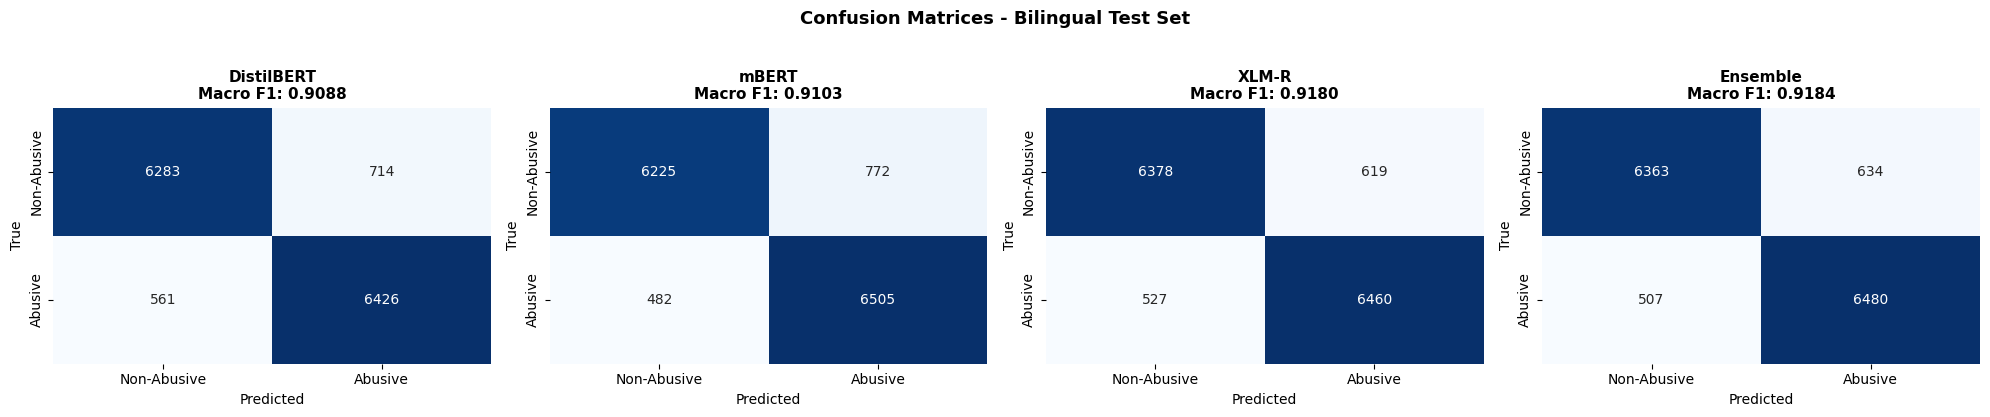

In [ ]:
fig,axes= plt.subplots(1, 4, figsize=(20, 4))
panel ={LABELS[m]: probs[(m, 'full')].argmax(1) for m in MODELS}
panel['Ensemble'] =ens_preds['full']

for ax, (name, p) in zip(axes, panel.items()):
    sns.heatmap(confusion_matrix(labels['full'], p), annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,xticklabels=['Non-Abusive', 'Abusive'],yticklabels=['Non-Abusive', 'Abusive'])
    ax.set_title(f"{name}\nMacro F1: {f1_score(labels['full'], p, average='macro'):.4f}",fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices - Bilingual Test Set', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{FIG}/all_models_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
c ='full'
y=labels[c]
singles= {m: f1_score(y, probs[(m, c)].argmax(1), average='macro') for m in MODELS}
best =max(singles, key=singles.get)
bp,ep= probs[(best, c)].argmax(1), ens_preds[c]
changed=bp != ep

wins= ((ep == y) & changed).sum()
losses=((bp == y) & changed).sum()
print(f"best single model: {LABELS[best]}")
print(f"rows where the ensemble differs: {changed.sum()} of {len(y)} ({100*changed.mean():.2f}%)")
if changed.sum():
    print(f"ensemble correct, {LABELS[best]} wrong: {wins}")
    print(f"{LABELS[best]} correct, ensemble wrong:{losses}")
    print(f"both wrong:{((ep != y) & (bp != y) & changed).sum()}")
    print(f"\n  net rows gained: {wins - losses:+d} out of {changed.sum()} changed")
    print(f"macro F1 change: {100*(f1_score(y, ep, average='macro') - singles[best]):+.2f}pp")

errs = np.stack([probs[(m, c)].argmax(1) != y for m in MODELS])
print(f"\nall three correct: {100*(~errs).all(0).mean():.2f}%"
      f" all three wrong: {100*errs.all(0).mean():.2f}%"
      f"({errs.all(0).sum()} rows)")


best single model: XLM-R
rows where the ensemble differs: 461 of 13984 (3.30%)
  ensemble correct, XLM-R wrong: 233
  XLM-R correct, ensemble wrong: 228
  both wrong:                            0

  net rows gained: +5 out of 461 changed
  macro F1 change: +0.04pp

all three correct: 86.81%   all three wrong: 4.75%  (664 rows)


Save

In [ ]:
def save_run(tag, preds, probs_arr, labels_arr, texts=None):
    from sklearn.metrics import classification_report
    probs_arr= np.asarray(probs_arr,dtype=np.float64)
    assert np.allclose(probs_arr.sum(1), 1, atol=1e-3)
    assert probs_arr[:, 1].max()> 0.75, f"{tag}: compressed probabilities"
    np.save(f'{SRC}/{tag}_preds.npy',np.asarray(preds))
    np.save(f'{SRC}/{tag}_probs.npy', probs_arr.astype(np.float32))
    np.save(f'{SRC}/{tag}_labels.npy',np.asarray(labels_arr))
    rep = classification_report(labels_arr, preds,target_names=['Non-Abusive', 'Abusive'],output_dict=True, digits=4)
    json.dump(rep, open(f'{SRC}/{tag}_metrics.json', 'w'), indent=2)
    if texts is not None:
        pd.DataFrame({'text': texts, 'true': labels_arr, 'pred': preds,'prob_abusive': probs_arr[:, 1]}).to_csv(f'{SRC}/{tag}_samples.csv', index=False)
    print(f"{tag:26s} n={len(preds):6d} macroF1 {rep['macro avg']['f1-score']:.4f} "
          f"NonAb {rep['Non-Abusive']['recall']:.4f} Ab {rep['Abusive']['recall']:.4f}")

for c in CONDITIONS:
    src=f'{SRC}/xlmr_bilingual_{c}_samples.csv'
    texts= pd.read_csv(src)['text'].tolist() if os.path.exists(src) else None
    save_run(f'ensemble_bilingual_{c}', ens_preds[c], ens_probs[c], labels[c], texts)

ensemble_bilingual_full    n= 13984 macroF1 0.9184 NonAb 0.9094 Ab 0.9274
ensemble_bilingual_en      n=  9843 macroF1 0.9309 NonAb 0.9239 Ab 0.9380
ensemble_bilingual_es      n=  4141 macroF1 0.8887 NonAb 0.8749 Ab 0.9024


## Summary

In [ ]:
print("=" * 62)
print("  ENSEMBLE RESULTS")
print("=" * 62)
for c in CONDITIONS:
    print(f"{NAMES[c]:22s} macro F1  {f1_score(labels[c], ens_preds[c], average='macro'):.4f}")
print()
print(gain_df.to_string(index=False))
print()
print(comparison_df.to_string(index=False))
print("=" * 62)

  ENSEMBLE RESULTS
  Bilingual (EN+ES)      macro F1  0.9184
  English subset         macro F1  0.9309
  Spanish subset         macro F1  0.8887

        Condition  distilbert  mbert   xlmr  Ensemble Best single  Gain (pp)  Unanimous (%)
Bilingual (EN+ES)      0.9088 0.9103 0.9180    0.9184        xlmr       0.04          91.55
   English subset      0.9261 0.9264 0.9297    0.9309        xlmr       0.12          93.70
   Spanish subset      0.8676 0.8719 0.8904    0.8887        xlmr      -0.17          86.45

     Model  Bilingual F1  EN F1  ES F1  EN-only  ES-only  EN→ES  ES→EN  EN-ES gap (pp)
  Ensemble        0.9184 0.9309 0.8887      NaN      NaN    NaN    NaN            4.22
     XLM-R        0.9180 0.9297 0.8904   0.9294   0.8860 0.4942 0.6313            3.93
     mBERT        0.9103 0.9264 0.8719   0.9257   0.8773 0.4077 0.5456            5.45
DistilBERT        0.9088 0.9261 0.8676   0.9262   0.8684 0.4301 0.5396            5.85
    BiLSTM        0.8864 0.9022 0.8490   0.9100   